In [1]:
import sqlalchemy as sa
from sqlalchemy import create_engine, URL, select
import urllib
import pyodbc

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
conn = urllib.parse.quote_plus(
    'Data Source Name=MySQLDataSource;'
    'Driver={SQL Server};'
    'Server=DESKTOP-KTVP4UP;'
    'Database=maven;'
    'Trusted_connection=yes;'
)

try:
    coxn = create_engine('mssql+pyodbc://?odbc_connect={}'.format(conn))
    print('Passed!')
except:
    print('Feild!')

Passed!


In [4]:
df = pd.read_sql('SELECT * FROM dbo.products', coxn)
df.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00.0000000,The Forever Love Bear
2,3,2013-12-12 09:00:00.0000000,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear


In [5]:
df1 = pd.read_sql('SELECT * FROM dbo.order_items', coxn)
df1.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46.0000000,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37.0000000,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45.0000000,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45.0000000,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15.0000000,5,1,1,49.99,19.49


In [6]:
df2 = pd.read_sql('SELECT * FROM dbo.order_item_refunds', coxn)
df2.head()

,order_item_refund_id,created_at,order_item_id,order_id,refund_amount_usd
0,1,2012-04-06 11:32:43.0000000,57,57,49.99
1,2,2012-04-13 01:09:43.0000000,74,74,49.99
2,3,2012-04-15 07:03:48.0000000,71,71,49.99
3,4,2012-04-17 20:00:37.0000000,118,118,49.99
4,5,2012-04-22 20:53:49.0000000,116,116,49.99


In [7]:
df3 = pd.read_sql('SELECT * FROM dbo.orders', coxn)
df3.head()

,order_id,created_at,website_session_id,user_id,primary_product_id,items_purchased,price_usd,cogs_usd
0,1,2012-03-19 10:42:46.0000000,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37.0000000,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45.0000000,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45.0000000,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15.0000000,177,177,1,1,49.99,19.49


In [8]:
df4 = pd.read_sql('SELECT * FROM dbo.website_pageviews', coxn)
df4.head()

,website_pageview_id,created_at,website_session_id,pageview_url
0,1,2012-03-19 08:04:16.0000000,1,/home
1,2,2012-03-19 08:16:49.0000000,2,/home
2,3,2012-03-19 08:26:55.0000000,3,/home
3,4,2012-03-19 08:37:33.0000000,4,/home
4,5,2012-03-19 09:00:55.0000000,5,/home


In [9]:
df5 = pd.read_sql('SELECT * FROM dbo.website_sessions', coxn)
df5.head()

,website_session_id,created_at,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16.0000000,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49.0000000,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55.0000000,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33.0000000,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55.0000000,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com


In [10]:
mergeDF = pd.merge(df1, df3, on='order_id', how='inner', sort=False)
mergeDF.head()

,order_item_id,created_at_x,order_id,product_id,is_primary_item,price_usd_x,cogs_usd_x,created_at_y,website_session_id,user_id,primary_product_id,items_purchased,price_usd_y,cogs_usd_y
0,1,2012-03-19 10:42:46.0000000,1,1,1,49.99,19.49,2012-03-19 10:42:46.0000000,20,20,1,1,49.99,19.49
1,2,2012-03-19 19:27:37.0000000,2,1,1,49.99,19.49,2012-03-19 19:27:37.0000000,104,104,1,1,49.99,19.49
2,3,2012-03-20 06:44:45.0000000,3,1,1,49.99,19.49,2012-03-20 06:44:45.0000000,147,147,1,1,49.99,19.49
3,4,2012-03-20 09:41:45.0000000,4,1,1,49.99,19.49,2012-03-20 09:41:45.0000000,160,160,1,1,49.99,19.49
4,5,2012-03-20 11:28:15.0000000,5,1,1,49.99,19.49,2012-03-20 11:28:15.0000000,177,177,1,1,49.99,19.49


In [11]:
dd = pd.read_sql("""select
                        p.product_name, 
                        o.price_usd 
                    from dbo.products as p 
                    left join dbo.orders as o 
                    on p.product_id = o.primary_product_id 
                    group by p.product_name, o.price_usd""", coxn)
dd

,product_name,price_usd
0,The Birthday Sugar Panda,105.98
1,The Birthday Sugar Panda,45.99
2,The Birthday Sugar Panda,75.98
3,The Birthday Sugar Panda,95.98
4,The Forever Love Bear,105.98
5,The Forever Love Bear,109.98
6,The Forever Love Bear,59.99
7,The Forever Love Bear,89.98
8,The Hudson River Mini bear,29.99
9,The Hudson River Mini bear,75.98


In [12]:
dd.columns

Index(['product_name', 'price_usd'], dtype='str')

In [13]:
dd['price_usd'] = dd['price_usd'].astype(float)

In [14]:
dd.dtypes

product_name        str
price_usd       float64
dtype: object

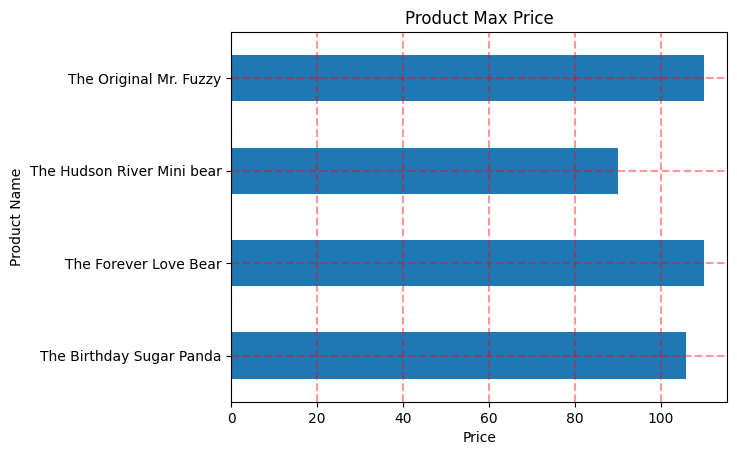

In [15]:
dd.groupby('product_name')['price_usd'].max().plot(kind='barh')
plt.ylabel('Product Name')
plt.xlabel('Price')
plt.title('Product Max Price')
plt.grid(color = 'red', alpha = 0.4, linestyle = '--', linewidth = 1.5)

Text(0.5, 1.0, 'Trafic Source')

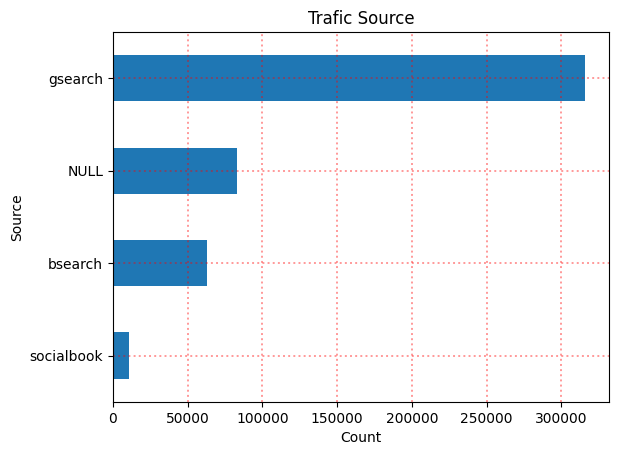

In [16]:
df5.utm_source.value_counts().sort_values(ascending=True).plot(kind='barh')
plt.xlabel('Count')
plt.ylabel('Source')
plt.grid(color='red', alpha=0.4, ls=':', lw=1.4)
plt.title("Trafic Source")

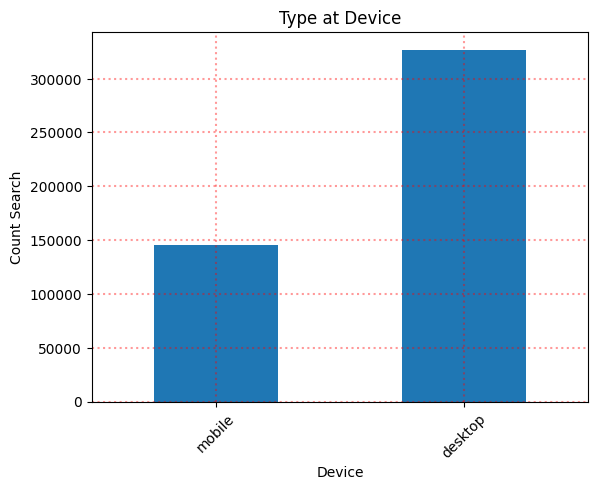

In [17]:
df5.device_type.value_counts().sort_values().plot(kind='bar')
plt.xticks(rotation=45)
plt.xlabel('Device')
plt.ylabel('Count Search')
plt.title("Type at Device")
plt.grid(color='red', alpha=0.4, ls=':', lw=1.5)

In [18]:
df.head()

,product_id,created_at,product_name
0,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy
1,2,2013-01-06 13:00:00.0000000,The Forever Love Bear
2,3,2013-12-12 09:00:00.0000000,The Birthday Sugar Panda
3,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear


In [19]:
df1.head()

,order_item_id,created_at,order_id,product_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 10:42:46.0000000,1,1,1,49.99,19.49
1,2,2012-03-19 19:27:37.0000000,2,1,1,49.99,19.49
2,3,2012-03-20 06:44:45.0000000,3,1,1,49.99,19.49
3,4,2012-03-20 09:41:45.0000000,4,1,1,49.99,19.49
4,5,2012-03-20 11:28:15.0000000,5,1,1,49.99,19.49


In [20]:
mergedf = pd.merge(df, df1, on='product_id', how='left')
mergedf

,product_id,created_at_x,product_name,order_item_id,created_at_y,order_id,is_primary_item,price_usd,cogs_usd
0,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy,1,2012-03-19 10:42:46.0000000,1,1,49.99,19.49
1,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy,2,2012-03-19 19:27:37.0000000,2,1,49.99,19.49
2,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy,3,2012-03-20 06:44:45.0000000,3,1,49.99,19.49
3,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy,4,2012-03-20 09:41:45.0000000,4,1,49.99,19.49
4,1,2012-03-19 08:00:00.0000000,The Original Mr. Fuzzy,5,2012-03-20 11:28:15.0000000,5,1,49.99,19.49
...,...,...,...,...,...,...,...,...,...
40020,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear,40015,2015-03-19 00:37:21.0000000,32304,0,29.99,9.49
40021,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear,40017,2015-03-19 01:42:17.0000000,32306,1,29.99,9.49
40022,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear,40021,2015-03-19 04:10:43.0000000,32310,1,29.99,9.49
40023,4,2014-02-05 10:00:00.0000000,The Hudson River Mini bear,40023,2015-03-19 05:27:28.0000000,32311,0,29.99,9.49


<Axes: ylabel='product_name,price_usd,cogs_usd'>

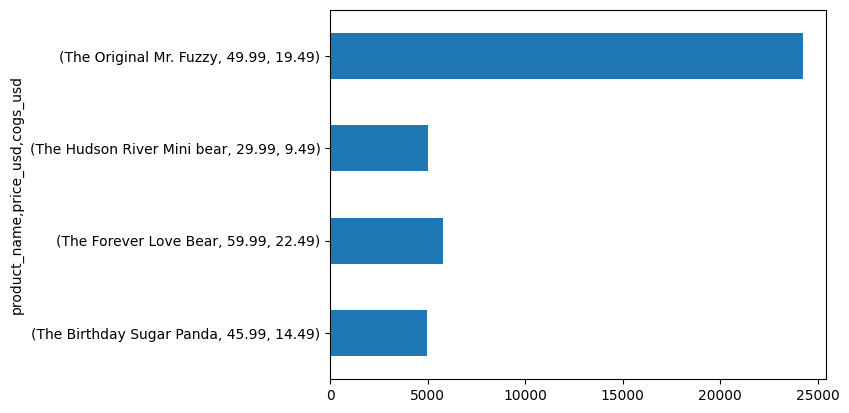

In [21]:
mergedf.groupby('product_name')[['price_usd', 'cogs_usd']].value_counts().plot(kind='barh')

In [22]:
merge_website = pd.merge(df4, df5, on='website_session_id', how='outer')
merge_website

,website_pageview_id,created_at_x,website_session_id,pageview_url,created_at_y,user_id,is_repeat_session,utm_source,utm_campaign,utm_content,device_type,http_referer
0,1,2012-03-19 08:04:16.0000000,1,/home,2012-03-19 08:04:16.0000000,1,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1,2,2012-03-19 08:16:49.0000000,2,/home,2012-03-19 08:16:49.0000000,2,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
2,3,2012-03-19 08:26:55.0000000,3,/home,2012-03-19 08:26:55.0000000,3,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
3,4,2012-03-19 08:37:33.0000000,4,/home,2012-03-19 08:37:33.0000000,4,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
4,5,2012-03-19 09:00:55.0000000,5,/home,2012-03-19 09:00:55.0000000,5,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
...,...,...,...,...,...,...,...,...,...,...,...,...
1188119,1188116,2015-03-19 07:55:40.0000000,472869,/lander-3,2015-03-19 07:55:40.0000000,394316,0,gsearch,nonbrand,g_ad_1,mobile,https://www.gsearch.com
1188120,1188118,2015-03-19 07:56:29.0000000,472870,/lander-5,2015-03-19 07:56:29.0000000,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
1188121,1188119,2015-03-19 07:57:22.0000000,472870,/products,2015-03-19 07:56:29.0000000,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com
1188122,1188121,2015-03-19 07:58:13.0000000,472870,/the-original-mr-fuzzy,2015-03-19 07:56:29.0000000,394317,0,gsearch,nonbrand,g_ad_1,desktop,https://www.gsearch.com


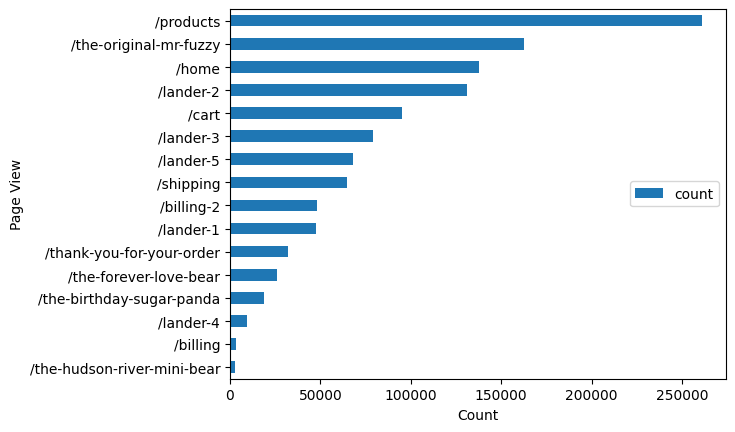

In [34]:
df4.pageview_url.value_counts().sort_values(ascending=True).plot(kind='barh')
plt.legend(loc=5)
plt.ylabel('Page View')
plt.xlabel('Count');